# Choosing a Clustering Method — Hands-on Tutorial

You now have three clustering tools, each with its own failure modes:

- **K-means** (NB 07) — fast, needs `K`, assumes round, similar-sized clusters
- **GMM** (NB 07) — elliptical clusters, soft assignments, still needs `K`
- **DBSCAN** (NB 08) — arbitrary shapes + noise, no `K`, but one density scale

There is **no universally best algorithm**. The right choice depends on what you
know about your data. This notebook makes that concrete: we'll run all three on a
zoo of datasets, watch each tool win and lose, and build a decision rule.

1. A zoo of datasets
2. All three methods, side by side
3. The decision guide
4. When methods *disagree* — and letting the silhouette arbitrate

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

np.random.seed(0)

PALETTE = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12', '#8e44ad']
def dbcolors(labels):
    return ['#bdc3c7' if l == -1 else PALETTE[l % len(PALETTE)] for l in labels]

---
## Part 1: A zoo of datasets

Five canonical shapes, each chosen to favour a different tool. Each entry carries the
hyperparameters we'll use later: `K` (for K-means/GMM) and `eps`/`min_samples` (DBSCAN).

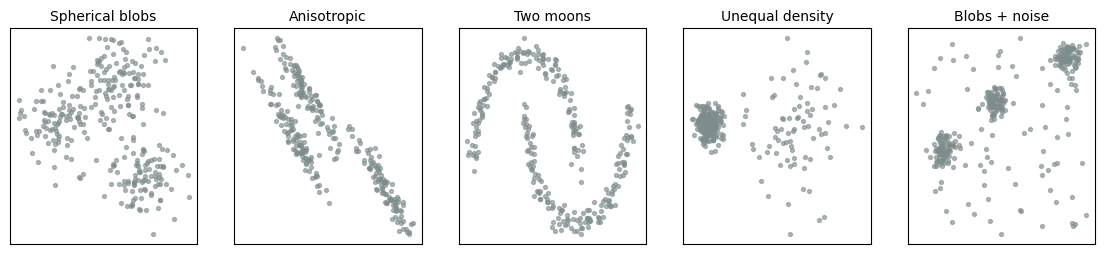

In [2]:
# Spherical, well-separated blobs (K known)
X_blobs, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=0)

# Anisotropic: sheared blobs -> elongated, tilted clusters
X_agg, _ = make_blobs(n_samples=300, random_state=170)
X_aniso = X_agg @ np.array([[0.6, -0.6], [-0.4, 0.8]])

# Non-convex: two interleaving moons
X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=0)

# Unequal density: a tight clump and a diffuse cloud
X_dense = np.random.randn(220, 2) * 0.35 + [-2, 0]
X_diff = np.random.randn(80, 2) * 1.3 + [3, 0]
X_density = np.vstack([X_dense, X_diff])

# Blobs in a sea of noise (outliers)
X_clean, _ = make_blobs(n_samples=250, centers=3, cluster_std=0.6, random_state=3)
X_noise = np.random.uniform(X_clean.min() - 1, X_clean.max() + 1, size=(80, 2))
X_outliers = np.vstack([X_clean, X_noise])

# (name, X, K, eps, min_samples)
ZOO = [
    ('Spherical blobs', X_blobs,    3, 0.9, 5),
    ('Anisotropic',     X_aniso,    3, 0.5, 5),
    ('Two moons',       X_moons,    2, 0.18, 5),
    ('Unequal density', X_density,  2, 0.5, 5),
    ('Blobs + noise',   X_outliers, 3, 0.6, 5),
]

fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), gridspec_kw={'wspace': 0.2})
for ax, (name, X, *_ ) in zip(axes, ZOO):
    ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.6, color='#7f8c8d')
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

### Think about it

- Look at each panel and *predict*, before running anything: which of the three tools
  will handle it cleanly, and which will mangle it?
- Two of these have no well-defined `K` by eye. Which two? That already rules a tool
  in or out for them.

---
## Part 2: All three methods, side by side

We'll cluster every dataset with each method and lay the results out in a grid:
rows = datasets, columns = methods. The winning tool for each row should jump out.

### Exercise: a method dispatcher

Write `cluster(method, X, K, eps, ms)` that returns the integer labels for the named
method.

**Hints:**
- `'kmeans'` -> `KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(X)`
- `'gmm'` -> `GaussianMixture(n_components=K, n_init=5, random_state=0).fit_predict(X)`
- `'dbscan'` -> `DBSCAN(eps=eps, min_samples=ms).fit_predict(X)`

In [ ]:
def cluster(method, X, K, eps, ms):
    # YOUR CODE HERE
    # if method is kmeans, then... 
    # Return integer labels for 'kmeans', 'gmm', or 'dbscan'.
    raise NotImplementedError("Implement the method dispatcher")

In [ ]:
methods = ['kmeans', 'gmm', 'dbscan']
fig, axes = plt.subplots(len(ZOO), len(methods) + 1,
                         figsize=(11, 2.2 * len(ZOO)),
                         gridspec_kw={'wspace': 0.1, 'hspace': 0.25})

for r, (name, X, K, eps, ms) in enumerate(ZOO):
    axes[r, 0].scatter(X[:, 0], X[:, 1], s=6, alpha=0.5, color='#7f8c8d')
    axes[r, 0].set_ylabel(name, fontsize=10)
    for c, method in enumerate(methods, start=1):
        labels = cluster(method, X, K, eps, ms)
        axes[r, c].scatter(X[:, 0], X[:, 1], s=6, alpha=0.6, c=dbcolors(labels))
        if r == 0:
            axes[r, c].set_title(method, fontsize=11)
    for c in range(len(methods) + 1):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_title('data', fontsize=11)
plt.show()

### Think about it

- **Spherical blobs**: all three basically agree. When the data is easy, the choice
  barely matters — so don't overthink it.
- **Anisotropic** and **unequal density**: where does K-means visibly fail, and does
  GMM rescue the anisotropic case? Why GMM and not DBSCAN there?
- **Two moons** and **blobs + noise**: only one tool gets these right. Which, and what
  property of the data made it the only option?
- Grey points in the DBSCAN column are **noise**. Is labelling some points "noise" a
  bug or a feature here?

---
## Part 3: The decision guide

Distilling the grid into a rule of thumb:

| What you know about the data | Reach for |
|---|---|
| Roughly round, similar-sized clusters; you know `K` | **K-means** |
| Elliptical / tilted clusters; you know `K` | **GMM** |
| Arbitrary shapes, or outliers you want flagged | **DBSCAN** |
| High-dimensional | **reduce first** (PCA), then one of the above |
| Nothing at all | start with K-means + elbow, *visualise*, iterate |

Two habits that matter more than the choice itself:

- **Always visualise.** If the clustering looks wrong, it is wrong.
- **Try more than one.** If methods agree, you can trust the structure. If they
  disagree, that disagreement is telling you something — Part 4.

---
## Part 4: When methods disagree

Agreement across methods is a cheap confidence check. When they *disagree*, you need a
referee that needs no labels — the **silhouette** score (full treatment in NB 10).

Here we score each method on the anisotropic dataset and let the number arbitrate.

### Score each method

Three candidate clusterings of `X_aniso` (`K=3`), and no labels — let the
**silhouette** referee. We compute it for each method below, excluding DBSCAN's
noise points (label `-1`) for a fair comparison and guarding the degenerate case
of fewer than two clusters.


In [ ]:
for method in ['kmeans', 'gmm', 'dbscan']:
    labels = cluster(method, X_aniso, 3, 0.5, 5)
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        score = silhouette_score(X_aniso[mask], labels[mask])
        print(f'{method:7s}: silhouette = {score:.3f}  ({mask.sum()} of {len(labels)} points scored)')
    else:
        print(f'{method:7s}: not enough clusters to score')


### Think about it

- Which method scored highest on the anisotropic blobs? Does the winner match what you
  judged by eye in Part 2?
- The silhouette only sees **geometry** — it can crown a clustering that's geometrically
  tidy but scientifically wrong (exactly the trap you'll hit on real pulsar data in
  NB 10). So treat it as a tie-breaker, not an oracle.
- Re-score on `X_moons`: silhouette tends to *punish* the correct moons clustering
  (the crescents aren't compact). What does that tell you about trusting a single
  internal metric across different cluster shapes?

---
## Part 5 — Pick K with the silhouette

Inertia (the elbow) only ever *falls* as you add clusters — it can't tell you when to
stop. The **mean silhouette** has an actual **peak**. Drag `K` and watch for it.

These are four clean, well-separated blobs. The clustering (left) and the per-point
silhouette plot (right) update together; the red dashed line is the mean score you'd
compare across different K.


In [ ]:
from ipywidgets import interact, IntSlider
from sklearn.metrics import silhouette_samples, silhouette_score

X_pick, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=0)

def explore_silhouette(K=2):
    km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_pick)
    labels = km.labels_
    sil = silhouette_samples(X_pick, labels)
    avg = silhouette_score(X_pick, labels)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'wspace': 0.2})
    # left: the clustering at this K
    for k in range(K):
        axL.scatter(X_pick[labels == k, 0], X_pick[labels == k, 1], s=12, alpha=0.6,
                    color=PALETTE[k % len(PALETTE)])
    axL.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker='X',
                s=120, color='black', edgecolors='white', linewidths=1.2, zorder=5)
    axL.set_title(f'K-means, K = {K}', fontsize=11)
    axL.set_xticks([]); axL.set_yticks([])
    # right: per-point silhouette, grouped by cluster and sorted
    y_lower = 0
    for k in range(K):
        vals = np.sort(sil[labels == k])
        axR.barh(range(y_lower, y_lower + len(vals)), vals, height=1.0,
                 color=PALETTE[k % len(PALETTE)], alpha=0.7)
        y_lower += len(vals) + 5
    axR.axvline(avg, color='#e74c3c', ls='--', label=f'mean = {avg:.3f}')
    axR.axvline(0, color='grey', lw=0.8)
    axR.set_xlabel('silhouette value'); axR.set_yticks([])
    axR.set_xlim(-0.4, 1.0)
    axR.set_title('per-point silhouette', fontsize=11)
    axR.legend(loc='lower right', fontsize=9)
    plt.show()

interact(explore_silhouette, K=IntSlider(min=2, max=8, step=1, value=2));


### Think about it

- At which `K` is the mean silhouette highest? Does it match the number of blobs you
  can see?
- Push `K` past the peak. Watch bars start to **dip below 0** — those points are now
  closer to a neighbouring cluster than their own.
- Inertia would keep dropping all the way to `K = 8`. Why does the silhouette turn
  around instead? (It charges you for *splitting* a real cluster.)
